# Quantum School: Day 1 - Lab
We have been using a visual editor to create quantum circuits throughout the first session. Now it's time to create some circuits on your own using qrisp, the next generation quantum programming framework!

In order to use qrisp together with IQM devices, please make sure to install the latest version of qrisp.

In [1]:
#!pip install --upgrade pip

In [2]:
#!pip install --no-cache --force-reinstall --upgrade "iqm-client>=32.1.1, <33.0" "qrisp[iqm]"

## Task 1: Signing up for IQM Resonance
If you do not have an IQM Resonance account, you can create an account [here](https://resonance.meetiqm.com/sign-up). Make sure to use an e-mail address you have access to, as you will need to verify it.

Your account will grant you monthly credits to run quantum circuits on IQM's quantum hardware. We will use this account throughout the exercises.

## Task 2: Creating different states

**Task 2.1: Run the code below that creates qubit states $|0\rangle$, $|1\rangle$, $|+\rangle$ and $|-\rangle$ using qrisp. Describe what results you get when measuring each state.**

In [3]:
from qrisp import *

# TODO: create single-qubit variables
zero = QuantumVariable(1)
one = QuantumVariable(1)
plus = QuantumVariable(1)
minus = QuantumVariable(1)

x(one)
h(plus)
h(x(minus))


print("|0>:")
print(zero.qs.statevector())
# Printing a QuantumVariable outputs the probability of measuring the qubit to be in each basis state.
print(zero)

print("\n|1>:")
print(one.qs.statevector())
print(one)

print("\n|+>:")
print(plus.qs.statevector())
print(plus)

print("\n|->:")
print(minus.qs.statevector())
print(minus)

|0>:
|0>ulating 1 qubits.. |                                                      | [  0%]
{'0': 1.0}                                                                           

|1>:
|1>                                                                                  
{'1': 1.0}                                                                           

|+>:
sqrt(2)*(|0> + |1>)/2                                                                
{'0': 0.5, '1': 0.5}                                                                 

|->:
sqrt(2)*(|0> - |1>)/2                                                                
{'0': 0.5, '1': 0.5}                                                                 


Up to a challenge? Try to create the states using different combinations of gates than shown in the code!

**Task 2.2 (Homework): Let's try something more complex. Create the state `sqrt(2)*(|0> + exp(3*I*pi/4)*|1>)/2` ($\approx 0.71|0\rangle + (-0.5+0.5i)|1\rangle$) using `x`, `h`, `t`, `z`, `y` or `s` gates.**

In [4]:
qubit = QuantumVariable(1)

# TODO: Apply gates to prepare the specified state
h(qubit)
s(qubit)
t(qubit)

print(qubit.qs.statevector())
print(qubit)

print(str(qubit.qs.statevector()) == "sqrt(2)*(|0> + exp(3*I*pi/4)*|1>)/2")

sqrt(2)*(|0> + exp(3*I*pi/4)*|1>)/2                                                  
{'0': 0.5, '1': 0.5}                                                                 
True                                                                                 


If you are curious about which state we created, you can apply the same operations on the Bloch sphere [here](https://www.iqmacademy.com/play/bloch/).

Obviously, we can also run the state creation on an actual quantum computer. However, we won't be able to get the quantum computer to tell us the state itself without a complicated process called state tomography.

## Task 3: Running circuits on IQM hardware

**Task 3.1: Modify the code below to evaluate some of the QuantumVariables you created in Task 2.1 on IQM's quantum hardware (zero, one, plus, minus).**

In [5]:

api_token = "kZRhVQdEjZNigffaT99achQVrvPc0+mbT3XnI8ghm5EBmt6h2wZyM5KFVSOHGqk0"

In [6]:
from qrisp.interface import IQMBackend
quantum_computer = IQMBackend(api_token = api_token,
                          device_instance = "sirius")

# The qv.get_measurement() function behaves just like print(qv), but we'll need to use get_measurement() to run on a real quantum computer.
zero.get_measurement(backend=quantum_computer)
one.get_measurement(backend=quantum_computer)
plus.get_measurement(backend=quantum_computer)
minus.get_measurement(backend=quantum_computer)

/Users/haslab-test/Desktop/iqm/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'1': 0.507, '0': 0.493}

# Task 4: Creating entanglement using qrisp

In this task we will be creating entanglement using **qrisp** and execute the circuits on a simulator as well as real hardware via **IQM Resonance**.


**Task 3.1: Execute the following code in your environment. It will create a Bell state and simulate it on the qrisp simulator.**

In [7]:
qv = QuantumVariable(3)
h(qv[0])
cx(qv[0],qv[1])
# The qv.get_measurement() function behaves just like print(qv), but we'll need to use get_measurement() to run on a real quantum computer.
qv.get_measurement()

{'000': 0.5, '110': 0.5}

Let's also take a look at the underlying circuit that was created. In `qrisp` this is done by accessing the `qs` attribute of the `QuantumVariable`.

In [8]:
print(qv.qs)

QuantumCircuit:
---------------
      ┌───┐     
qv.0: ┤ H ├──■──
      └───┘┌─┴─┐
qv.1: ─────┤ X ├
           └───┘
qv.2: ──────────
                
Live QuantumVariables:
----------------------
QuantumVariable qv


Oh no, we actually wanted to create a GHZ state with 3 qubits! Let's fix that by adding another CNOT gate to the circuit above.

**Task 3.2: Modify the code above to create a GHZ state with 3 qubits instead of a Bell state with 2 qubits. Simulate the modified circuit on the qrisp simulator.**

In [9]:
qv = QuantumVariable(3)
h(qv[0])
cx(qv[0],qv[1])
cx(qv[1],qv[2])
qv.get_measurement()

{'000': 0.5, '111': 0.5}

In [10]:
print(qv.qs)

QuantumCircuit:
---------------
      ┌───┐          
qv.0: ┤ H ├──■───────
      └───┘┌─┴─┐     
qv.1: ─────┤ X ├──■──
           └───┘┌─┴─┐
qv.2: ──────────┤ X ├
                └───┘
Live QuantumVariables:
----------------------
QuantumVariable qv


Simulating a GHZ state on the qrisp simulator is great, but you know what is even better? Running it on real quantum hardware!

Now update the below code to run the circuit on IQM Resonance hardware. You will need to provide your API key (available in your IQM Resonance account drawer). Also, make sure to check the website to verify that the device you are choosing is currently online.

In [11]:
from qrisp.interface import IQMBackend
quantum_computer = IQMBackend(api_token = api_token,
                          device_instance = "sirius")

qv.get_measurement(backend=quantum_computer)

{'111': 0.459,
 '000': 0.407,
 '110': 0.04,
 '011': 0.04,
 '100': 0.02,
 '001': 0.018,
 '101': 0.013,
 '010': 0.003}

**Task 3.3: Repeat the above experiment, but this time create a GHZ state with at least 10 qubits. How does the result on the quantum hardware compare to the simulated results? Why?**

Answer: The quantum hardware produces a mostly random state instead of the GHZ state. This is because creating a big GHZ state requires a lot of operations, which means that the quantum computer has to avoid introducing too much noise (which randomizes quantum states) for a long time and over many operations. If we aren't thoughtful about how we implement the circuit on the physical hardware, we just get too much noise and don't get our desired result. We'll discuss this issue much more in lecture 5 when we discuss transpilation, compilation, and optimization.

In [12]:
qv = QuantumVariable(10)
h(qv[0])
for i in range(1,10):
    cx(qv[i-1],qv[i])

print(qv.get_measurement())

print(qv.qs)

{'0000000000': 0.5, '1111111111': 0.5}                                               
QuantumCircuit:
---------------
      ┌───┐                                             
qv.0: ┤ H ├──■──────────────────────────────────────────
      └───┘┌─┴─┐                                        
qv.1: ─────┤ X ├──■─────────────────────────────────────
           └───┘┌─┴─┐                                   
qv.2: ──────────┤ X ├──■────────────────────────────────
                └───┘┌─┴─┐                              
qv.3: ───────────────┤ X ├──■───────────────────────────
                     └───┘┌─┴─┐                         
qv.4: ────────────────────┤ X ├──■──────────────────────
                          └───┘┌─┴─┐                    
qv.5: ─────────────────────────┤ X ├──■─────────────────
                               └───┘┌─┴─┐               
qv.6: ──────────────────────────────┤ X ├──■────────────
                                    └───┘┌─┴─┐          
qv.7: ─────────────────────

OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [13]:
from qrisp.interface import IQMBackend
quantum_computer = IQMBackend(api_token = api_token,
                          device_instance = "sirius")

qv.get_measurement(backend=quantum_computer)

{'0000000000': 0.217,
 '1111111111': 0.119,
 '1000000000': 0.067,
 '0111111111': 0.047,
 '1100000000': 0.021,
 '1111000000': 0.021,
 '1111111110': 0.018,
 '1111111101': 0.016,
 '0000111111': 0.016,
 '1111111011': 0.014,
 '0000001111': 0.014,
 '1111110111': 0.013,
 '0001111111': 0.012,
 '0111111011': 0.011,
 '1111011111': 0.011,
 '0011111111': 0.011,
 '1110000000': 0.01,
 '0111000000': 0.01,
 '1111110000': 0.009,
 '0000000011': 0.009,
 '0000011111': 0.009,
 '0110000000': 0.008,
 '0000000001': 0.008,
 '0100000000': 0.007,
 '1000111111': 0.007,
 '0101111111': 0.007,
 '1111100000': 0.006,
 '1101111111': 0.006,
 '0111100000': 0.005,
 '1111111100': 0.005,
 '0000001011': 0.005,
 '1000001111': 0.005,
 '1111101111': 0.005,
 '1001111111': 0.005,
 '0001000000': 0.004,
 '1111111000': 0.004,
 '0111111110': 0.004,
 '1000000011': 0.004,
 '1000000111': 0.004,
 '1001000000': 0.003,
 '1101000000': 0.003,
 '0011000000': 0.003,
 '0000100000': 0.003,
 '0111110000': 0.003,
 '0000000100': 0.003,
 '0000000010

# Task 4: Optimize the GHZ circuit for the topology

The GHZ circuit we created is essentially one long chain of qubits. So given the architecture of the quantum computer, we can try to optimize the circuit to better fit the hardware topology.

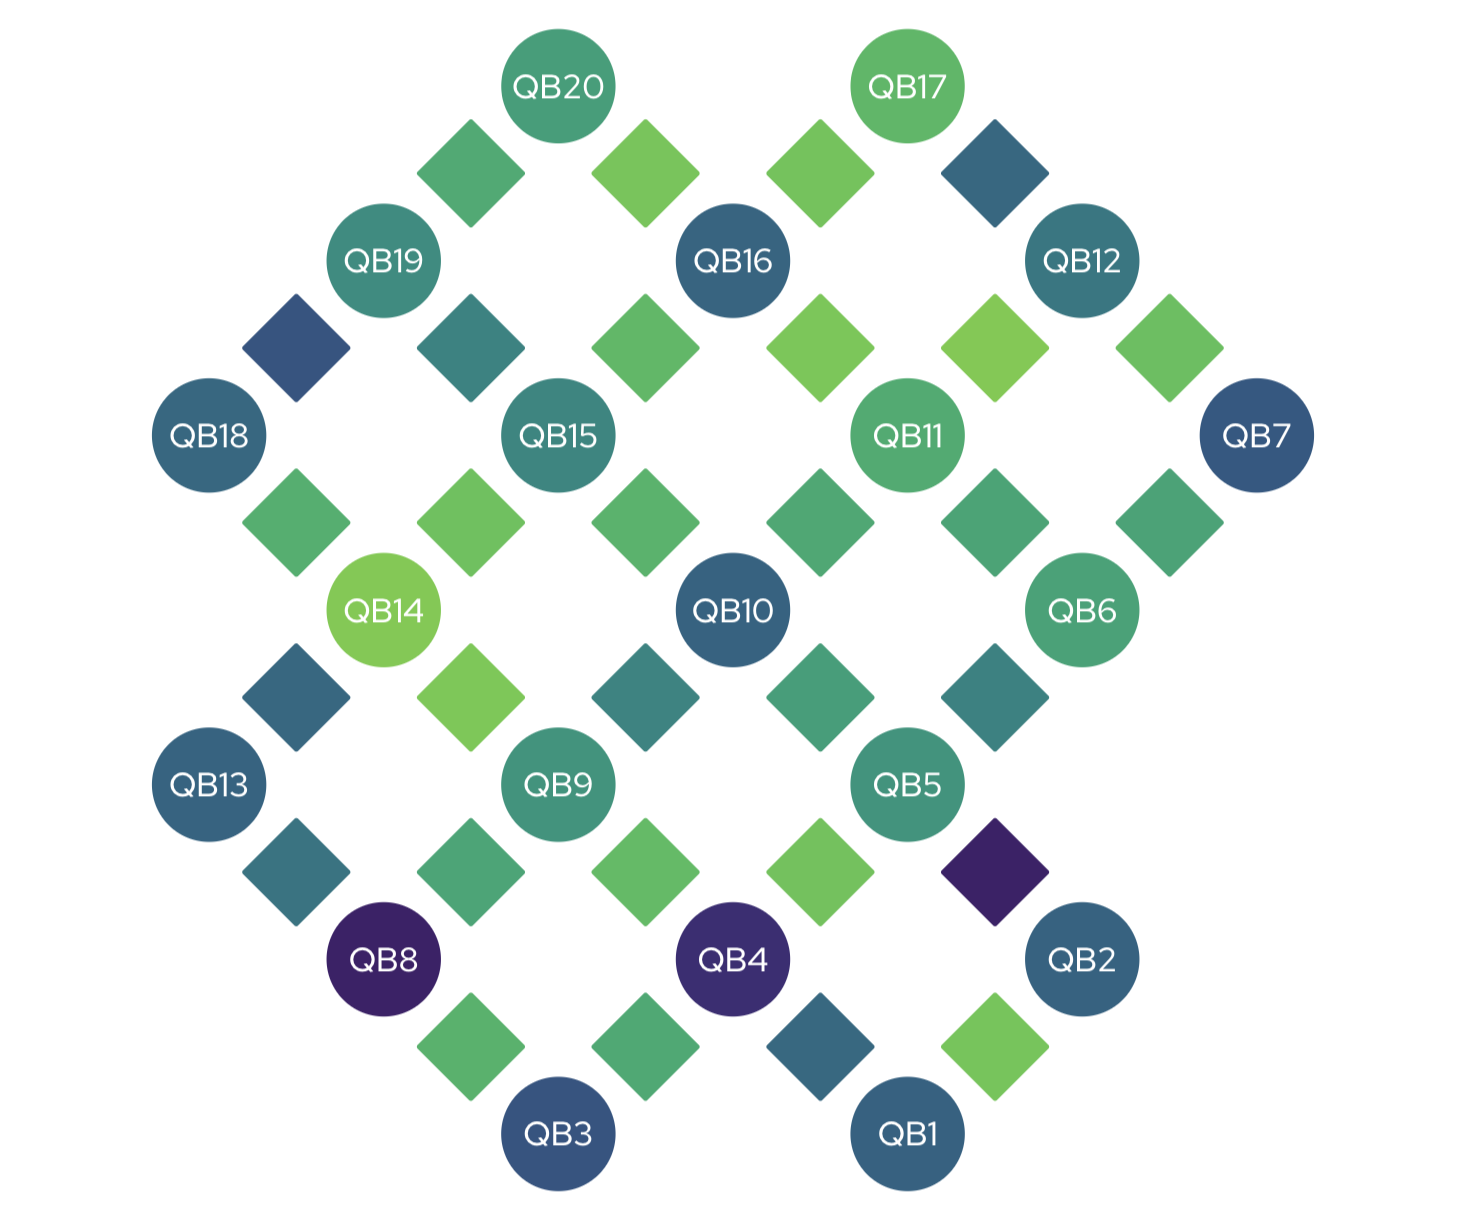

**Task 4.1: Adapt the GHZ circuit to reflect the connectivity given by the device. You can check the connectivity for any given device on IQM Resonance.

In [14]:
ghz_con = QuantumVariable(10)
#Garnet
h(ghz_con[6])
cx(ghz_con[6],ghz_con[5])
cx(ghz_con[5],ghz_con[4])
cx(ghz_con[4],ghz_con[9])
cx(ghz_con[9],ghz_con[8])
cx(ghz_con[8],ghz_con[7])
cx(ghz_con[7],ghz_con[2])
cx(ghz_con[2],ghz_con[3])
cx(ghz_con[3],ghz_con[0])
cx(ghz_con[0],ghz_con[1])
ghz_con.get_measurement()

{'0000000000': 0.5, '1111111111': 0.5}

## Outlook: More qrispy content

Qrisp offers plenty more of in-built functionality. More data types (hello `QuantumFloat`, `QuantumModulus`, ...), arithmetic operations, built-in algorithm primitives (more on this at a later stage).

For now, let's see some other data types available in qrisp! One that is used, for example, in Shor's algorithm is the Quantum Modulus type. It represents elements of a residue class ring, that is, integers modulo $n$.

**Task 4.3: Run the code snippet below, then play with the parameters to make sure you understand how QuantumModulus works.**

In [15]:
qm = QuantumModulus(3)  # represent elements of Z/ 3Z
qm[:] = 2
print(qm)

{2: 1.0}                                                                             


In [16]:
qm2 = qm + qm # addition in Z/3Z
print(qm2)

{1: 1.0}                                                                             


### Quantum Arrays

Qrisp also supports Quantum Arrays, which are collections of quantum variables. You can create a Quantum Array like this:

```python
qa = QuantumArray(qtype = QuantumVariable(1), shape = 4)  # Creates a Quantum Array of 4 qubits
```

**Task 4.4: fill in the code below to use the QuantumArray data type to create a GHZ state with 10 qubits and run it on a real quantum computer.**

In [17]:
qa = QuantumArray(qtype = QuantumVariable(1), shape = 10)  # Creates a Quantum Array of 10 qubits

def GHZ(qv):
    # TODO: implement GHZ state preparation
    h(qa[0])
    for i in range(1,10):
        cx(qa[i-1],qa[i])
    pass

GHZ(qa)

print(qa)
print(qa.qs)

print(qa.get_measurement(backend=quantum_computer))

{OutcomeArray(['0', '0', '0', '0', '0', '0', '0', '0', '0', '0'],                    
             dtype=object): 0.5, OutcomeArray(['1', '1', '1', '1', '1', '1', '1', '1', '1', '1'],
             dtype=object): 0.5}
QuantumCircuit:
---------------
        ┌───┐                                             
  qa.0: ┤ H ├──■──────────────────────────────────────────
        └───┘┌─┴─┐                                        
qa_1.0: ─────┤ X ├──■─────────────────────────────────────
             └───┘┌─┴─┐                                   
qa_2.0: ──────────┤ X ├──■────────────────────────────────
                  └───┘┌─┴─┐                              
qa_3.0: ───────────────┤ X ├──■───────────────────────────
                       └───┘┌─┴─┐                         
qa_4.0: ────────────────────┤ X ├──■──────────────────────
                            └───┘┌─┴─┐                    
qa_5.0: ─────────────────────────┤ X ├──■─────────────────
                                 └───┘┌─┴─┐